Khám phá độc lập từng bảng -> Kiểm tra tính toàn vẹn -> Join và phân tích chuyên sâu cho bài toán

MỤC TIÊU: tìm ra đặc tính dữ liệu
- Data quality (dữ liệu có bị thiếu, trùng lặp, giá trị lạ ?)
- Feature potential (đánh giá dữ liệu có đủ để làm bài toán cross-selling + thời gian + địa điểm không)
- Pattern discovery (tìm quy luật tự nhiên trong dữ liệu)

Vì đây là bài toán cross-selling dựa trên ngữ cảnh (thời gian và địa điểm)
=> Các bảng cần dùng:
- olist_orders_dataset: chứa thông tin đơn hàng và thời gian
- olist_order_items_dataset: chứa chi tiết sản phẩm trong mỗi đơn hàng
- olist_products_dataset (chứa tên/danh mục sản phẩm)
- olist_customers_dataset (chứa vị trí địa lí của khách hàng)  

In [209]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.sql.functions import udf
from pyspark.sql.types import ArrayType, StringType
from pyspark.sql.types import StructType, StructField


spark = SparkSession.builder \
    .appName("Olist_EDA") \
    .getOrCreate()

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


## KIỂM TRA CHẤT LƯỢNG TỪNG BẢNG

### Hàm cho mỗi bảng

In [210]:
def profile_data(df, table_name, key_cols=None):
    """
    key_cols: list các cột được coi là primary key của bảng
              Nếu không truyền thì bỏ qua bước kiểm tra duplicate theo key
    """
    total = df.count()
    print(f"\n{'='*50}")
    print(f"  BẢNG: {table_name}")
    print(f"{'='*50}")

    # 1. Tổng quan
    print(f"\n[1] TỔNG QUAN")
    print(f"  Số dòng  : {total:,}")
    print(f"  Số cột   : {len(df.columns)}")
    print(f"  Columns  : {df.columns}")

    # 2. Schema
    print(f"\n[2] SCHEMA")
    df.printSchema()

    # 3. Null
    print(f"\n[3] GIÁ TRỊ NULL")
    null_counts = df.select([
        F.count(F.when(F.col(c).isNull(), c)).alias(c)
        for c in df.columns
    ])
    null_row = null_counts.collect()[0].asDict()
    has_null = False
    for col, cnt in null_row.items():
        if cnt > 0:
            pct = cnt / total * 100
            print(f"  {col}: {cnt:,} null ({pct:.1f}%)")
            has_null = True
    if not has_null:
        print("  Không có null nào!")

    # 4. Duplicate — toàn bộ dòng
    print(f"\n[4] TRÙNG LẶP")
    distinct_count = df.distinct().count()
    full_dup = total - distinct_count
    print(f"  Dòng trùng hoàn toàn: {full_dup:,}")

    # 4b. Duplicate theo key 
    if key_cols:
        key_distinct = df.select(key_cols).distinct().count()
        key_dup = total - key_distinct
        print(f"  Dòng trùng theo key {key_cols}: {key_dup:,}")
        if key_dup > 0:
            print(f"Key không unique — cần điều tra thêm!")

    # 5. Sample
    print(f"\n[5] MẪU DỮ LIỆU (5 dòng đầu)")
    df.show(5, truncate=False)

### OLIST_PRODUCTS_DATASET

In [211]:
df_products = spark.read.csv("/home/jovyan/work/data/olist_products_dataset.csv", header=True, inferSchema=True)
profile_data(df_products,"products", key_cols=["product_id"])


  BẢNG: products

[1] TỔNG QUAN
  Số dòng  : 32,951
  Số cột   : 9
  Columns  : ['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']

[2] SCHEMA
root
 |-- product_id: string (nullable = true)
 |-- product_category_name: string (nullable = true)
 |-- product_name_lenght: integer (nullable = true)
 |-- product_description_lenght: integer (nullable = true)
 |-- product_photos_qty: integer (nullable = true)
 |-- product_weight_g: integer (nullable = true)
 |-- product_length_cm: integer (nullable = true)
 |-- product_height_cm: integer (nullable = true)
 |-- product_width_cm: integer (nullable = true)


[3] GIÁ TRỊ NULL
  product_category_name: 610 null (1.9%)
  product_name_lenght: 610 null (1.9%)
  product_description_lenght: 610 null (1.9%)
  product_photos_qty: 610 null (1.9%)
  product_weight_g: 2 null (0.0%)
  product_length_cm: 2 null (0.0%

### OLIST_CUSTOMERS_DATASET

In [212]:
df_customers = spark.read.csv("/home/jovyan/work/data/olist_customers_dataset.csv", header=True, inferSchema=True)
profile_data(df_customers,"customers", key_cols=["customer_id"])


  BẢNG: customers

[1] TỔNG QUAN
  Số dòng  : 99,441
  Số cột   : 5
  Columns  : ['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']

[2] SCHEMA
root
 |-- customer_id: string (nullable = true)
 |-- customer_unique_id: string (nullable = true)
 |-- customer_zip_code_prefix: integer (nullable = true)
 |-- customer_city: string (nullable = true)
 |-- customer_state: string (nullable = true)


[3] GIÁ TRỊ NULL
  Không có null nào!

[4] TRÙNG LẶP
  Dòng trùng hoàn toàn: 0
  Dòng trùng theo key ['customer_id']: 0

[5] MẪU DỮ LIỆU (5 dòng đầu)
+--------------------------------+--------------------------------+------------------------+---------------------+--------------+
|customer_id                     |customer_unique_id              |customer_zip_code_prefix|customer_city        |customer_state|
+--------------------------------+--------------------------------+------------------------+---------------------+--------------+
|06b8999e2fba1a1f

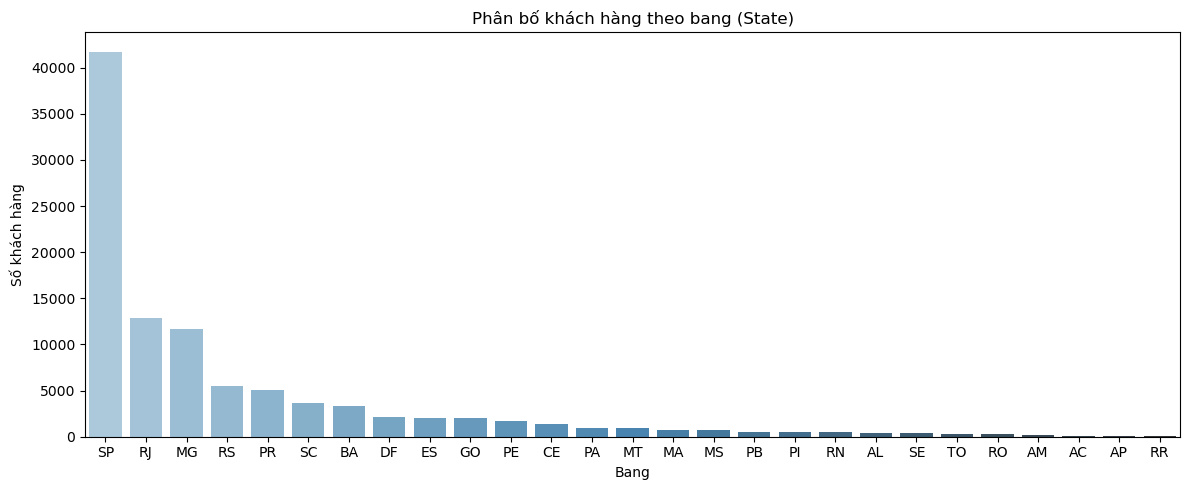

In [213]:
# đếm theo bang
state_counts = (
    df_customers
    .groupBy("customer_state")
    .count()
    .orderBy("count", ascending=False)
)

# Chuyển sang pandas để vẽ
df_state = state_counts.toPandas()

# Vẽ
plt.figure(figsize=(12, 5))
sns.barplot(data=df_state, x="customer_state", y="count", palette="Blues_d")
plt.title("Phân bố khách hàng theo bang (State)")
plt.xlabel("Bang")
plt.ylabel("Số khách hàng")
plt.tight_layout()
plt.show()

### OLIST_ORDERS_DATASET

In [214]:
df_orders = spark.read.csv("/home/jovyan/work/data/olist_orders_dataset.csv", header=True, inferSchema=True)
profile_data(df_orders,"orders", key_cols=["order_id"])


  BẢNG: orders

[1] TỔNG QUAN
  Số dòng  : 99,441
  Số cột   : 8
  Columns  : ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

[2] SCHEMA
root
 |-- order_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- order_status: string (nullable = true)
 |-- order_purchase_timestamp: timestamp (nullable = true)
 |-- order_approved_at: timestamp (nullable = true)
 |-- order_delivered_carrier_date: timestamp (nullable = true)
 |-- order_delivered_customer_date: timestamp (nullable = true)
 |-- order_estimated_delivery_date: timestamp (nullable = true)


[3] GIÁ TRỊ NULL
  order_approved_at: 160 null (0.2%)
  order_delivered_carrier_date: 1,783 null (1.8%)
  order_delivered_customer_date: 2,965 null (3.0%)

[4] TRÙNG LẶP
  Dòng trùng hoàn toàn: 0
  Dòng trùng theo key ['order_id']: 0

[5] MẪU DỮ LIỆU (5 dòng đầu)
+-----------------

In [215]:
# Bảng tổng hợp trạng thái đơn hàng
df_orders.groupBy("order_status").count().show()

# Giao hàng trước khi đặt? (vô lý về mặt logic)
invalid_orders = df_orders.filter(F.col("order_purchase_timestamp") > F.col("order_delivered_customer_date"))
print(f"Số đơn hàng có thời gian lỗi logic: {invalid_orders.count()}")

# Tìm các đơn hàng trạng thái 'delivered' nhưng thiếu ngày giao
missing_delivery_date = df_orders.filter(
    (F.col("order_status") == "delivered") & 
    (F.col("order_delivered_customer_date").isNull())
)


# Tìm các đơn hàng trạng thái 'delivered' nhưng thiếu ngày duyệt đơn
missing_approved_at = df_orders.filter(
    (F.col("order_status") == "delivered") & 
    (F.col("order_approved_at").isNull())
)

print(f"Số đơn 'delivered' bị thiếu ngày giao hàng: {missing_delivery_date.count()}")
print(f"Số đơn 'delivered' bị thiếu ngày duyệt: {missing_approved_at.count()}")


+------------+-----+
|order_status|count|
+------------+-----+
|     shipped| 1107|
|    canceled|  625|
|    invoiced|  314|
|     created|    5|
|   delivered|96478|
| unavailable|  609|
|  processing|  301|
|    approved|    2|
+------------+-----+

Số đơn hàng có thời gian lỗi logic: 0
Số đơn 'delivered' bị thiếu ngày giao hàng: 8
Số đơn 'delivered' bị thiếu ngày duyệt: 14


In [216]:
if missing_delivery_date.count() > 0:
    print("Mẫu các đơn hàng thiếu ngày giao hàng:")
    missing_delivery_date.show(8)

Mẫu các đơn hàng thiếu ngày giao hàng:
+--------------------+--------------------+------------+------------------------+-------------------+----------------------------+-----------------------------+-----------------------------+
|            order_id|         customer_id|order_status|order_purchase_timestamp|  order_approved_at|order_delivered_carrier_date|order_delivered_customer_date|order_estimated_delivery_date|
+--------------------+--------------------+------------+------------------------+-------------------+----------------------------+-----------------------------+-----------------------------+
|2d1e2d5bf4dc7227b...|ec05a6d8558c6455f...|   delivered|     2017-11-28 17:44:07|2017-11-28 17:56:40|         2017-11-30 18:12:23|                         null|          2017-12-18 00:00:00|
|f5dd62b788049ad9f...|5e89028e024b381dc...|   delivered|     2018-06-20 06:58:43|2018-06-20 07:19:05|         2018-06-25 08:05:00|                         null|          2018-07-16 00:00:00|
|2ebdf

In [217]:
if missing_approved_at.count() > 0:
    print("Mẫu các đơn hàng thiếu ngày duyệt:")
    missing_approved_at.show(14)

Mẫu các đơn hàng thiếu ngày duyệt:
+--------------------+--------------------+------------+------------------------+-----------------+----------------------------+-----------------------------+-----------------------------+
|            order_id|         customer_id|order_status|order_purchase_timestamp|order_approved_at|order_delivered_carrier_date|order_delivered_customer_date|order_estimated_delivery_date|
+--------------------+--------------------+------------+------------------------+-----------------+----------------------------+-----------------------------+-----------------------------+
|e04abd8149ef81b95...|2127dc6603ac33544...|   delivered|     2017-02-18 14:40:00|             null|         2017-02-23 12:04:47|          2017-03-01 13:25:33|          2017-03-17 00:00:00|
|8a9adc69528e1001f...|4c1ccc74e00993733...|   delivered|     2017-02-18 12:45:31|             null|         2017-02-23 09:01:52|          2017-03-02 10:05:06|          2017-03-21 00:00:00|
|7013bcfc1c97fe719..

### OLIST_ORDER_ITEMS_DATASET

In [218]:
df_order_items = spark.read.csv("/home/jovyan/work/data/olist_order_items_dataset.csv", header=True, inferSchema=True)
profile_data(df_order_items,"order_items", key_cols=["order_id", "order_item_id"])


  BẢNG: order_items

[1] TỔNG QUAN
  Số dòng  : 112,650
  Số cột   : 7
  Columns  : ['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

[2] SCHEMA
root
 |-- order_id: string (nullable = true)
 |-- order_item_id: integer (nullable = true)
 |-- product_id: string (nullable = true)
 |-- seller_id: string (nullable = true)
 |-- shipping_limit_date: timestamp (nullable = true)
 |-- price: double (nullable = true)
 |-- freight_value: double (nullable = true)


[3] GIÁ TRỊ NULL
  Không có null nào!

[4] TRÙNG LẶP
  Dòng trùng hoàn toàn: 0
  Dòng trùng theo key ['order_id', 'order_item_id']: 0

[5] MẪU DỮ LIỆU (5 dòng đầu)
+--------------------------------+-------------+--------------------------------+--------------------------------+-------------------+-----+-------------+
|order_id                        |order_item_id|product_id                      |seller_id                       |shipping_limit_date|price|freight_value|
+----------

In [219]:
# 1. Thống kê mô tả toàn diện
stats = df_order_items.select("price", "freight_value").describe()
stats.show()

# 2. Tính các phân vị (Percentiles) chi tiết hơn 25, 75
quantiles = df_order_items.select(
    F.percentile_approx("price", [0.25, 0.5, 0.75, 0.95, 0.99]).alias("price_quantiles"),
    F.percentile_approx("freight_value", [0.25, 0.5, 0.75, 0.95, 0.99]).alias("freight_quantiles")
)
quantiles.show(truncate=False)

# Có price = 0 hoặc âm không?
print("Số dòng price <= 0:", df_order_items.filter(F.col("price") <= 0).count())
print("Số dòng freight <= 0:", df_order_items.filter(F.col("freight_value") <= 0).count())

+-------+------------------+------------------+
|summary|             price|     freight_value|
+-------+------------------+------------------+
|  count|            112650|            112650|
|   mean|120.65373901464174|19.990319928982977|
| stddev| 183.6339280502595|15.806405412297098|
|    min|              0.85|               0.0|
|    max|            6735.0|            409.68|
+-------+------------------+------------------+

+----------------------------------+-----------------------------------+
|price_quantiles                   |freight_quantiles                  |
+----------------------------------+-----------------------------------+
|[39.9, 74.99, 134.9, 349.9, 889.0]|[13.08, 16.26, 21.15, 45.12, 84.15]|
+----------------------------------+-----------------------------------+

Số dòng price <= 0: 0
Số dòng freight <= 0: 383


In [220]:
# 1. Đọc bảng translation trước
df_translation = spark.read.csv("/home/jovyan/work/data/product_category_name_translation.csv", header=True, inferSchema=True)

# 2. Chạy chuỗi lệnh gộp: Lọc -> Join Products -> Join Translation -> Group -> Count -> Order
df_zero_freight_translated = df_order_items.filter(F.col("freight_value") == 0) \
    .join(df_products.select("product_id", "product_category_name"), on="product_id", how="left") \
    .join(df_translation, on="product_category_name", how="left") \
    .groupBy("product_category_name_english") \
    .count() \
    .orderBy("count", ascending=False)

# 3. Hiển thị kết quả
df_zero_freight_translated.show(10)

+-----------------------------+-----+
|product_category_name_english|count|
+-----------------------------+-----+
|                watches_gifts|  214|
|              furniture_decor|   98|
|                 garden_tools|   56|
|               bed_bath_table|    9|
|                         null|    2|
|               books_imported|    1|
|                health_beauty|    1|
|             office_furniture|    1|
|                         auto|    1|
+-----------------------------+-----+



In [221]:
# Kiểm tra 610 sản phẩm null category đó có thực sự xuất hiện trong đơn hàng không?

null_products = df_products.filter(F.col("product_category_name").isNull()) \
                            .select("product_id")

# Join với order_items để xem chúng có được bán không → Sẽ xử lý bằng cách gán nhãn "unknown" ở Silver layer
null_in_orders = df_order_items.join(null_products, on="product_id", how="inner")
print(f"Số dòng order_items chứa sản phẩm không có category: {null_in_orders.count()}")

Số dòng order_items chứa sản phẩm không có category: 1603


## JOIN BẢNG KIỂM TRA CHO BÀI TOÁN CROSS SELLING

In [222]:
# Đọc bảng translation để chuẩn bị join
df_translation = spark.read.csv("/home/jovyan/work/data/product_category_name_translation.csv", header=True, inferSchema=True)
print("Bảng translation:")
df_translation.show(5)

Bảng translation:
+---------------------+-----------------------------+
|product_category_name|product_category_name_english|
+---------------------+-----------------------------+
|         beleza_saude|                health_beauty|
| informatica_acess...|         computers_accesso...|
|           automotivo|                         auto|
|      cama_mesa_banho|               bed_bath_table|
|     moveis_decoracao|              furniture_decor|
+---------------------+-----------------------------+
only showing top 5 rows



In [223]:
# Lọc chỉ lấy đơn delivered và không có lỗi logic thời gian
orders_clean = df_orders.filter(F.col("order_status") == "delivered") \
    .filter(F.col("order_delivered_customer_date").isNotNull()) \
    .filter(F.col("order_approved_at").isNotNull()) \
    .filter(
        F.col("order_delivered_customer_date") >= F.col("order_purchase_timestamp")
    )

print(f"Tổng đơn ban đầu     : {df_orders.count():,}")
print(f"Đơn delivered + sạch : {orders_clean.count():,}")
print(f"Đã loại bỏ           : {df_orders.count() - orders_clean.count():,} đơn")

Tổng đơn ban đầu     : 99,441
Đơn delivered + sạch : 96,456
Đã loại bỏ           : 2,985 đơn


In [224]:
df_base = orders_clean \
    .join(df_order_items, on="order_id", how="inner") \
    .join(
        df_products.select("product_id", "product_category_name"),
        on="product_id", how="left"
    ) \
    .join(
        df_translation,
        on="product_category_name", how="left"
    ) \
    .join(
        df_customers.select("customer_id", "customer_unique_id", "customer_state"),
        on="customer_id", how="left"
    )

print(f"Số dòng sau join: {df_base.count():,}")
print(f"Số cột          : {len(df_base.columns)}")
df_base.printSchema()

# Kiểm tra số lượng sản phẩm null 'toàn tập'
null_content_check = df_base.filter(F.col("product_category_name").isNull()) \
    .select("product_id").distinct().count()

print(f"Số lượng product_id không có bất kỳ thông tin danh mục nào: {null_content_check}/{df_base.select('product_id').distinct().count()}")


Số dòng sau join: 110,174
Số cột          : 18
root
 |-- customer_id: string (nullable = true)
 |-- product_category_name: string (nullable = true)
 |-- product_id: string (nullable = true)
 |-- order_id: string (nullable = true)
 |-- order_status: string (nullable = true)
 |-- order_purchase_timestamp: timestamp (nullable = true)
 |-- order_approved_at: timestamp (nullable = true)
 |-- order_delivered_carrier_date: timestamp (nullable = true)
 |-- order_delivered_customer_date: timestamp (nullable = true)
 |-- order_estimated_delivery_date: timestamp (nullable = true)
 |-- order_item_id: integer (nullable = true)
 |-- seller_id: string (nullable = true)
 |-- shipping_limit_date: timestamp (nullable = true)
 |-- price: double (nullable = true)
 |-- freight_value: double (nullable = true)
 |-- product_category_name_english: string (nullable = true)
 |-- customer_unique_id: string (nullable = true)
 |-- customer_state: string (nullable = true)

Số lượng product_id không có bất kỳ thông t

In [225]:
# 1. Lấy danh sách các order_id có ít nhất 1 sản phẩm bị null category
orders_with_null_cat = df_base.filter(F.col("product_category_name").isNull()) \
    .select("order_id") \
    .distinct()

# 2. Đếm số lượng đơn hàng vô danh
count_null_orders = orders_with_null_cat.count()

# 3. Đếm tổng số đơn hàng hiện có trong df_base
total_orders = df_base.select("order_id").distinct().count()

# 4. Tính tỷ lệ phần trăm
percent_null_orders = (count_null_orders / total_orders) * 100

# 5. In kết quả
print("-" * 50)
print(f"THỐNG KÊ ĐƠN HÀNG VÔ DANH (NULL CATEGORY)")
print(f"Số đơn hàng có mặt hàng vô danh : {count_null_orders:,}")
print(f"Tổng số đơn hàng hiện có       : {total_orders:,}")
print(f"Tỷ lệ đơn hàng dính 'null'      : {percent_null_orders:.2f}%")
print("-" * 50)

--------------------------------------------------
THỐNG KÊ ĐƠN HÀNG VÔ DANH (NULL CATEGORY)
Số đơn hàng có mặt hàng vô danh : 1,391
Tổng số đơn hàng hiện có       : 96,456
Tỷ lệ đơn hàng dính 'null'      : 1.44%
--------------------------------------------------


Số lượng đơn bị null cate chiếm 1.44% -> lỗi dữ liệu này không làm biến dạng xu hướng chung của toàn bộ tập dữ liệu. Xóa

In [226]:
# Danh mục có trong bảng Products nhưng không có trong bảng Translation
list_in_products = df_products.select("product_category_name").distinct()
list_in_translation = df_translation.select("product_category_name").distinct()

missing_categories = list_in_products.join(list_in_translation, on="product_category_name", how="left_anti")

print("Danh mục tồn tại trong sản phẩm nhưng không có trong file dịch:")
missing_categories.show()

Danh mục tồn tại trong sản phẩm nhưng không có trong file dịch:
+---------------------+
|product_category_name|
+---------------------+
|             pc_gamer|
|                 null|
| portateis_cozinha...|
+---------------------+




Kết quả left_anti join cho thấy có 3 nhóm chính bị thiếu bản dịch tiếng Anh:
- pc_gamer: Danh mục này tồn tại trong bảng sản phẩm nhưng file dịch không có.
- portateis_cozinha_e_preparadores_de_alimentos: Đây cũng là danh mục thiếu bản dịch.
- null: Đây chính là nhóm nằm trong 610 sản phâm bị null category_name

Bước tiếp theo khi Join cần thêm tên tiếng anh của 2 danh mục này và bỏ đi các đơn có category name null vì dù có lập được luật kết hợp cũng không cho ra được ý nghĩa gì vì không biết được danh tính sp đó

In [227]:
df_base = orders_clean \
    .join(df_order_items, on="order_id", how="inner") \
    .join(
        # Vá trực tiếp tại đây bằng withColumn
        df_products.select("product_id", "product_category_name") \
            .filter(F.col("product_category_name").isNotNull()) \
            .withColumn("product_category_name_english_fixed", 
                F.when(F.col("product_category_name") == "pc_gamer", "pc_gamer")
                 .when(F.col("product_category_name") == "portateis_cozinha_e_preparadores_de_alimentos", "kitchen_portables")
                 .otherwise(None)),
        on="product_id", how="inner"
    ) \
    .join(
        df_translation,
        on="product_category_name", how="left"
    ) \
    .join(
        df_customers.select("customer_id", "customer_unique_id", "customer_state"),
        on="customer_id", how="left"
    ) \
    .withColumn(
        # Hợp nhất tên dịch: Ưu tiên cột vừa vá -> rồi mới đến bảng dịch
        "product_category_name_english", 
        F.coalesce(F.col("product_category_name_english_fixed"), F.col("product_category_name_english"))
    ) \
    .drop("product_category_name_english_fixed") \
    .filter(F.col("product_category_name_english").isNotNull()) #xóa đi các product_id có category_name null dẫn tới trans không có

# Kiểm tra kết quả
df_base.filter(F.col("product_category_name").isin("pc_gamer", "portateis_cozinha_e_preparadores_de_alimentos")) \
       .select("product_category_name", "product_category_name_english").show(3)

# In kết quả kiểm tra
print(f"Số dòng sau join: {df_base.count():,}")
print(f"Số cột          : {len(df_base.columns)}")
df_base.select("product_category_name", "product_category_name_english").show(5)

+---------------------+-----------------------------+
|product_category_name|product_category_name_english|
+---------------------+-----------------------------+
| portateis_cozinha...|            kitchen_portables|
|             pc_gamer|                     pc_gamer|
| portateis_cozinha...|            kitchen_portables|
+---------------------+-----------------------------+
only showing top 3 rows

Số dòng sau join: 108,638
Số cột          : 18
+---------------------+-----------------------------+
|product_category_name|product_category_name_english|
+---------------------+-----------------------------+
| utilidades_domest...|                   housewares|
|           perfumaria|                    perfumery|
|           automotivo|                         auto|
|             pet_shop|                     pet_shop|
|            papelaria|                   stationery|
+---------------------+-----------------------------+
only showing top 5 rows



Bảng chỉ có product_id dài và không có tên sản phẩm cụ thể cho từng cá thể
Nhưng bảng có product_category_name -> lập tên cho sản phẩm theo công thức: [tên danh mục tiếng Anh] + "-" + [thứ hạng tần suất được mua nhiều trong danh mục]

In [228]:
# 1. Tính số lượng đơn hàng cho mỗi sản phẩm
prod_counts = df_base.groupBy("product_id", "product_category_name_english") \
    .agg(F.count("order_id").alias("order_count"))

# 2. Định nghĩa Window: Chia theo danh mục, sắp xếp theo số lượng mua giảm dần
window_spec = Window.partitionBy("product_category_name_english").orderBy(F.col("order_count").desc())

# 3. Tính rank
df_ranked = prod_counts.withColumn("product_rank", F.row_number().over(window_spec))

# In thử 10 dòng để kiểm tra
df_ranked.select("product_category_name_english", "product_id", "order_count", "product_rank") \
    .orderBy("product_category_name_english", "product_rank") \
    .show(40, truncate=False)

+-----------------------------+--------------------------------+-----------+------------+
|product_category_name_english|product_id                      |order_count|product_rank|
+-----------------------------+--------------------------------+-----------+------------+
|agro_industry_and_commerce   |11250b0d4b709fee92441c5f34122aed|22         |1           |
|agro_industry_and_commerce   |423a6644f0aa529e8828ff1f91003690|18         |2           |
|agro_industry_and_commerce   |672e757f331900b9deea127a2a7b79fd|17         |3           |
|agro_industry_and_commerce   |a0fe1efb855f3e786f0650268cd77f44|13         |4           |
|agro_industry_and_commerce   |3bebad3cf2c8d1a8d3ce97174643e054|13         |5           |
|agro_industry_and_commerce   |b5aebb467d9a92162173cbd234e00d99|10         |6           |
|agro_industry_and_commerce   |980ecbcc15fe174ec1e5757c4d75b1bf|8          |7           |
|agro_industry_and_commerce   |16d096faa27582985f849f08370cf1ed|8          |8           |
|agro_indu

In [229]:
# Join bảng rank vào df_base
df_base = df_base.join(
    df_ranked.select("product_id", "product_rank"),
    on="product_id", 
    how="left"
)

# Tạo cột product_name bằng cách nối chuỗi (concat)
# Lưu ý: Dùng F.coalesce để tránh lỗi nếu tên danh mục bị Null
df_base = df_base.withColumn(
    "product_name",
    F.concat(
        F.coalesce(F.col("product_category_name_english"), F.lit("unknown")),
        F.lit("-"),
        F.col("product_rank").cast("string")
    )
)

# Kiểm tra kết quả cuối cùng
df_base.select("product_id", "product_category_name_english", "product_rank", "product_name").show(10)

+--------------------+-----------------------------+------------+-------------------+
|          product_id|product_category_name_english|product_rank|       product_name|
+--------------------+-----------------------------+------------+-------------------+
|d0b61bfb1de832b15...|                     pet_shop|          82|        pet_shop-82|
|060cb19345d90064d...|                         auto|          15|            auto-15|
|65266b2da20d04dbe...|                   stationery|           4|       stationery-4|
|4520766ec412348b8...|                         auto|           6|             auto-6|
|ac1789e492dcd698c...|              furniture_decor|         912|furniture_decor-912|
|595fac2a385ac33a8...|                    perfumery|           2|        perfumery-2|
|aa4383b373c6aca5d...|                         auto|         220|           auto-220|
|08574b074924071f4...|                 garden_tools|          10|    garden_tools-10|
|08574b074924071f4...|                 garden_tools|  

+------------+-----+
|num_products|count|
+------------+-----+
|           1|91984|
|           2| 2763|
|           3|  289|
|           4|   67|
|           5|    8|
|           6|   10|
|           7|    3|
|           8|    1|
+------------+-----+



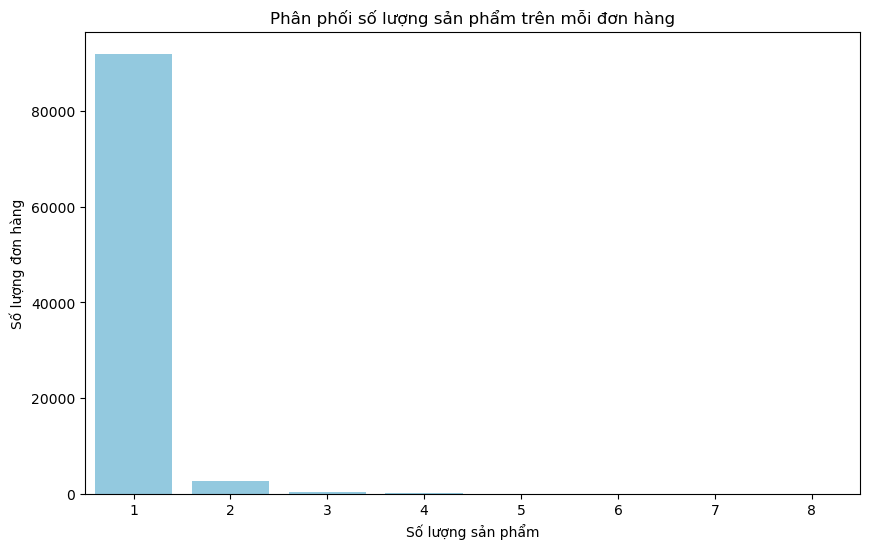

In [230]:
# bao nhiêu đơn có > 1 sản phẩm?
basket_size = df_base.groupBy("order_id") \
    .agg(F.countDistinct("product_id").alias("num_products"))

basket_dist = basket_size.groupBy("num_products") \
    .count() \
    .orderBy("num_products")

basket_dist.show(10)
# Chuyển đổi dữ liệu sang Pandas
pdf_basket = basket_dist.toPandas()

# Vẽ biểu đồ cột
plt.figure(figsize=(10, 6))
sns.barplot(data=pdf_basket, x='num_products', y='count', color='skyblue')
plt.title('Phân phối số lượng sản phẩm trên mỗi đơn hàng')
plt.xlabel('Số lượng sản phẩm')
plt.ylabel('Số lượng đơn hàng')
plt.show()


Đơn có > 1 sản phẩm: 3,141 / 95,125 (3.3%)


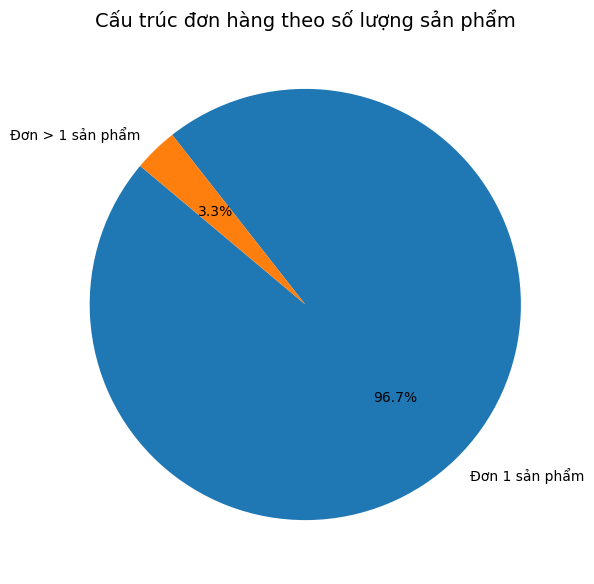

In [231]:
# 1. Tính toán tập trung (Chỉ dùng 1 lần count tổng, sau đó tính toán dựa trên biến đã có)
total_orders = basket_size.count()
multi_product_orders = basket_size.filter(F.col("num_products") > 1).count()
single_product_orders = total_orders - multi_product_orders

# 2. In thông tin (Sử dụng f-string cho gọn)
percent_multi = (multi_product_orders / total_orders) * 100
print(f"Đơn có > 1 sản phẩm: {multi_product_orders:,} / {total_orders:,} ({percent_multi:.1f}%)")

# 3. Vẽ biểu đồ
labels = ['Đơn 1 sản phẩm', 'Đơn > 1 sản phẩm']
sizes = [single_product_orders, multi_product_orders]

plt.figure(figsize=(7, 7))
plt.pie(sizes, 
        labels=labels, 
        autopct='%1.1f%%', 
        startangle=140)

plt.title('Cấu trúc đơn hàng theo số lượng sản phẩm', fontsize=14)
plt.show()

## PHÂN TÍCH CHUNG
Tiếp theo là các kiểm tra tổng quan cho dữ liệu theo thời gian và theo bang để đánh giá tính phù hợp cho bài toán cross-selling.

#### Phân tích chung theo địa lý
Xem xét phân phối theo bang để hiểu vị trí và tiềm năng cross-selling theo vùng.

In [232]:
#  Phân phối theo bang (địa điểm)
df_base.groupBy("customer_state") \
    .agg(F.countDistinct("order_id").alias("num_orders")) \
    .orderBy("num_orders", ascending=False) \
    .show(10)

+--------------+----------+
|customer_state|num_orders|
+--------------+----------+
|            SP|     39952|
|            RJ|     12166|
|            MG|     11187|
|            RS|      5267|
|            PR|      4855|
|            SC|      3491|
|            BA|      3215|
|            DF|      2050|
|            ES|      1978|
|            GO|      1911|
+--------------+----------+
only showing top 10 rows



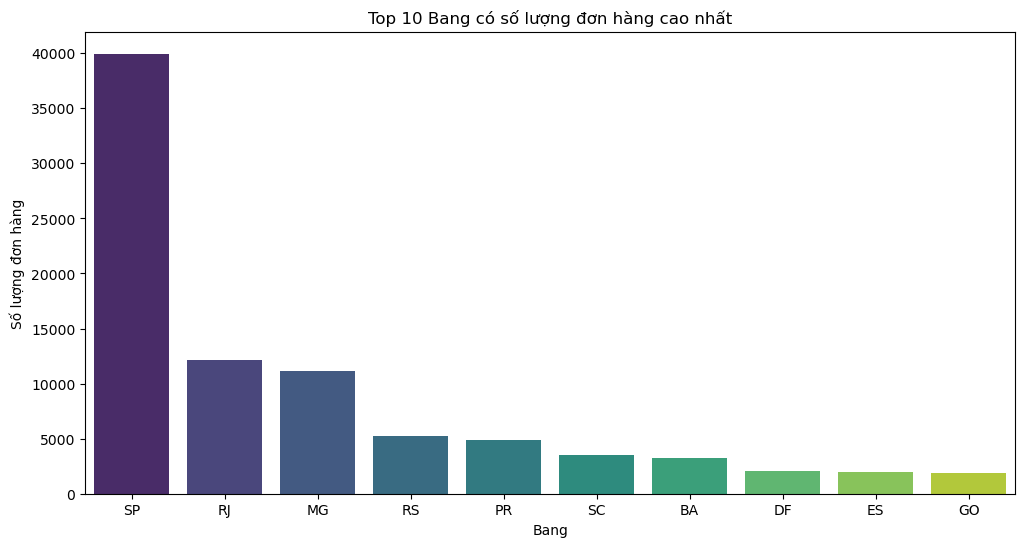

In [233]:
# vẽ biểu đồ
# Chuyển đổi dữ liệu từ Spark sang Pandas
pdf_state = df_base.groupBy("customer_state") \
    .agg(F.countDistinct("order_id").alias("num_orders")) \
    .orderBy("num_orders", ascending=False) \
    .toPandas()

# 2. Vẽ biểu đồ
plt.figure(figsize=(12, 6))
sns.barplot(x='customer_state', y='num_orders', data=pdf_state.head(10), palette='viridis')
plt.title('Top 10 Bang có số lượng đơn hàng cao nhất')
plt.xlabel('Bang')
plt.ylabel('Số lượng đơn hàng')
plt.show()

In [234]:
# Top categories by state
from pyspark.sql.functions import countDistinct

top_cat_by_state = df_base \
    .groupBy("customer_state", "product_category_name_english") \
    .agg(countDistinct("order_id").alias("num_orders")) \
    .orderBy("customer_state", "num_orders", ascending=[True, False])

# Get top 3 categories per state

window_spec = Window.partitionBy("customer_state").orderBy(F.col("num_orders").desc())
top_cat_by_state = top_cat_by_state.withColumn("rank", F.row_number().over(window_spec)) \
    .filter(F.col("rank") <= 3) \
    .drop("rank")

top_cat_by_state.show(50)

+--------------+-----------------------------+----------+
|customer_state|product_category_name_english|num_orders|
+--------------+-----------------------------+----------+
|            AC|               sports_leisure|         9|
|            AC|              furniture_decor|         7|
|            AC|         computers_accesso...|         6|
|            AL|                health_beauty|        62|
|            AL|                watches_gifts|        34|
|            AL|         computers_accesso...|        32|
|            AM|                health_beauty|        15|
|            AM|                    telephony|        14|
|            AM|               sports_leisure|        12|
|            AP|                health_beauty|        10|
|            AP|                watches_gifts|         7|
|            AP|               sports_leisure|         6|
|            BA|                health_beauty|       319|
|            BA|               sports_leisure|       250|
|            B

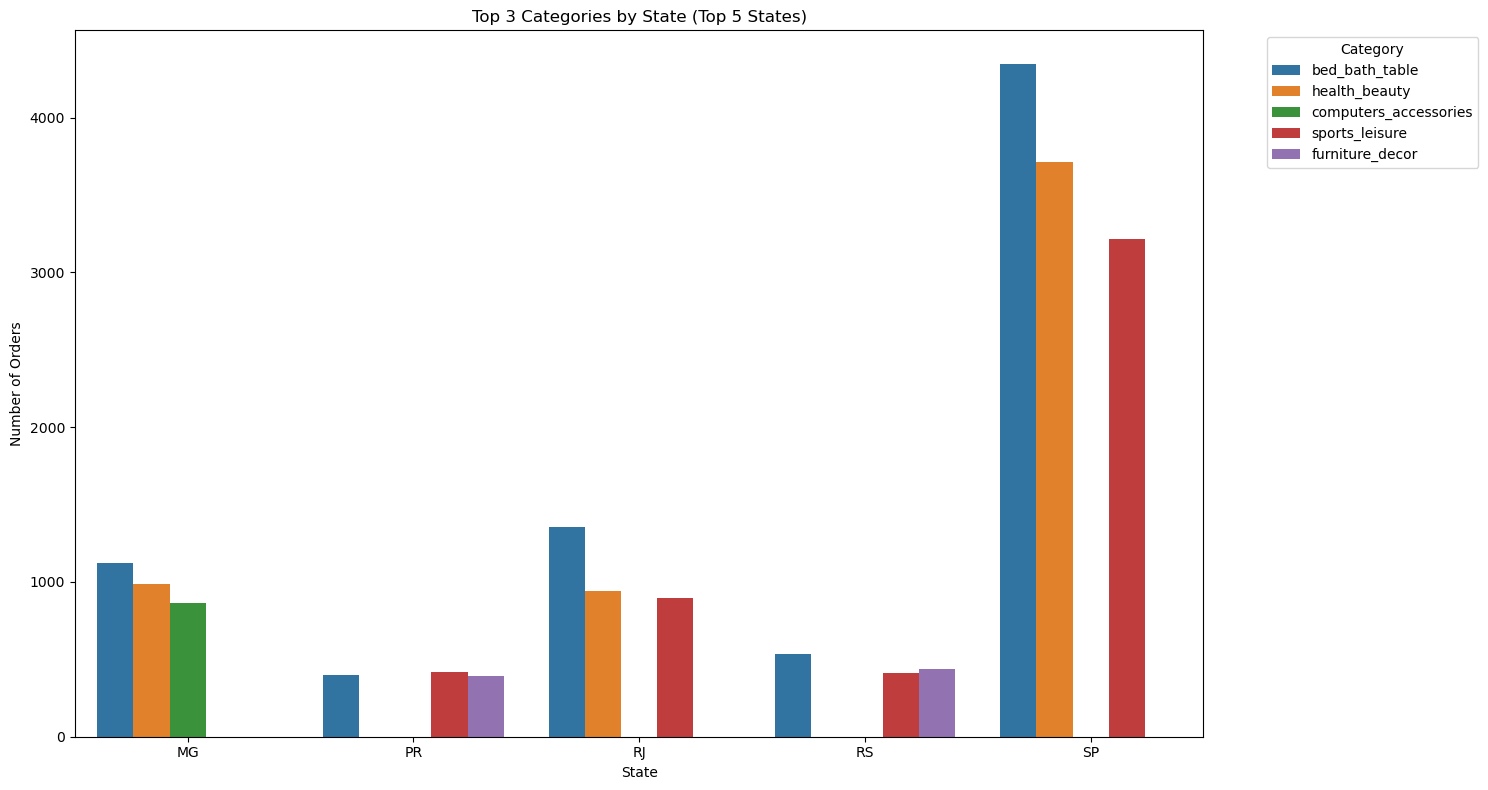

In [235]:
# Visualize top categories for top 5 states
top_states = ["SP", "RJ", "MG", "RS", "PR"]  # Based on earlier analysis

pdf_top_cat = top_cat_by_state.filter(F.col("customer_state").isin(top_states)).toPandas()

plt.figure(figsize=(15, 8))
sns.barplot(data=pdf_top_cat, x="customer_state", y="num_orders", hue="product_category_name_english")
plt.title("Top 3 Categories by State (Top 5 States)")
plt.xlabel("State")
plt.ylabel("Number of Orders")
plt.legend(title="Category", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

#### Phân tích chung theo thời gian
Các phân tích sau đây mô tả xu hướng số đơn theo giờ, theo tháng và theo khung thời gian trong ngày.

In [236]:
df_base = df_base.withColumn("year",      F.year("order_purchase_timestamp")) \
                 .withColumn("month",     F.month("order_purchase_timestamp")) \
                 .withColumn("hour",      F.hour("order_purchase_timestamp")) \
                 .withColumn("dayofweek", F.dayofweek("order_purchase_timestamp"))
# dayofweek: 1=Chủ nhật, 2=Thứ 2, ..., 7=Thứ 7

In [237]:
# Theo tháng
df_base.groupBy("year", "month") \
    .agg(F.countDistinct("order_id").alias("num_orders")) \
    .orderBy("year", "month") \
    .show(30)

# Theo giờ trong ngày
df_base.groupBy("hour") \
    .agg(F.countDistinct("order_id").alias("num_orders")) \
    .orderBy("hour") \
    .show(24)

+----+-----+----------+
|year|month|num_orders|
+----+-----+----------+
|2016|    9|         1|
|2016|   10|       263|
|2016|   12|         1|
|2017|    1|       738|
|2017|    2|      1592|
|2017|    3|      2496|
|2017|    4|      2243|
|2017|    5|      3466|
|2017|    6|      3085|
|2017|    7|      3824|
|2017|    8|      4129|
|2017|    9|      4091|
|2017|   10|      4428|
|2017|   11|      7186|
|2017|   12|      5383|
|2018|    1|      6901|
|2018|    2|      6450|
|2018|    3|      6884|
|2018|    4|      6731|
|2018|    5|      6716|
|2018|    6|      6075|
|2018|    7|      6118|
|2018|    8|      6324|
+----+-----+----------+

+----+----------+
|hour|num_orders|
+----+----------+
|   0|      2290|
|   1|      1119|
|   2|       487|
|   3|       256|
|   4|       201|
|   5|       177|
|   6|       469|
|   7|      1181|
|   8|      2874|
|   9|      4579|
|  10|      5895|
|  11|      6290|
|  12|      5713|
|  13|      6224|
|  14|      6285|
|  15|      6171|
|  16|   

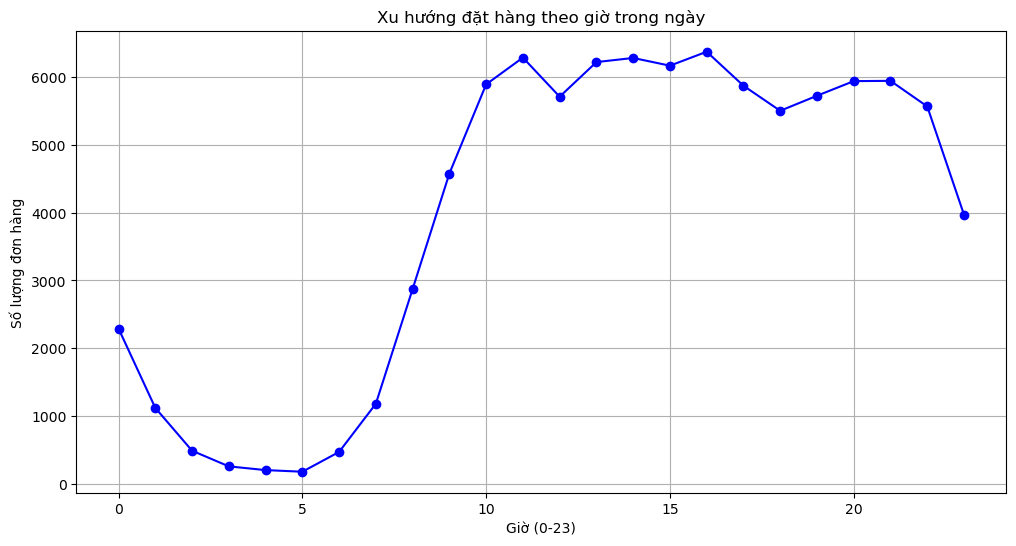

In [238]:
# 1. Chuyển đổi dữ liệu
pdf_hour = df_base.groupBy("hour") \
    .agg(F.countDistinct("order_id").alias("num_orders")) \
    .orderBy("hour") \
    .toPandas()

# 2. Vẽ biểu đồ đường
plt.figure(figsize=(12, 6))
plt.plot(pdf_hour['hour'], pdf_hour['num_orders'], marker='o', linestyle='-', color='b')
plt.title('Xu hướng đặt hàng theo giờ trong ngày')
plt.xlabel('Giờ (0-23)')
plt.ylabel('Số lượng đơn hàng')
plt.grid(True)
plt.show()

/tmp/ipykernel_272/3153232607.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pdf_filtered['time_segment'] = pd.Categorical(pdf_filtered['time_segment'], categories=time_order, ordered=True)


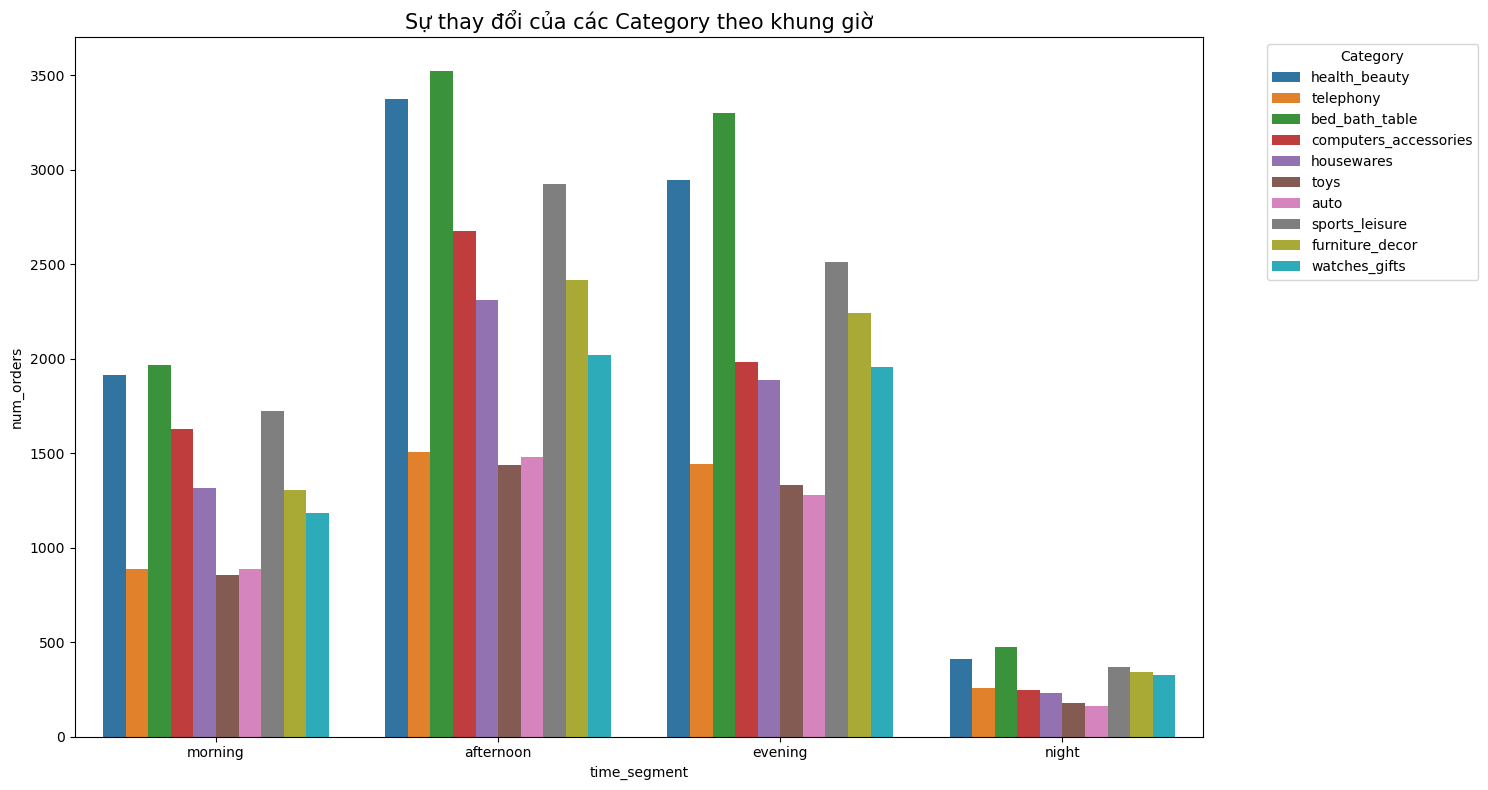

In [239]:
# 1. Sử dụng df_base đã có translation
df_base_with_segment = df_base.withColumn("time_segment",
    F.when((F.col("hour") >= 6)  & (F.col("hour") < 12), "morning")
     .when((F.col("hour") >= 12) & (F.col("hour") < 18), "afternoon")
     .when((F.col("hour") >= 18) & (F.col("hour") < 24), "evening")
     .otherwise("night")
)

# 3. Chuyển đổi sang Pandas (Sử dụng tên tiếng Anh để nhóm)
pdf = df_base_with_segment.groupBy("time_segment", "product_category_name_english") \
    .agg(F.countDistinct("order_id").alias("num_orders")) \
    .toPandas()

# 4. Lọc Top 10 Category (dùng tên tiếng Anh)
top_categories = pdf.groupby('product_category_name_english')['num_orders'].sum().nlargest(10).index
pdf_filtered = pdf[pdf['product_category_name_english'].isin(top_categories)]

# 5. Sắp xếp thứ tự thời gian
time_order = ['morning', 'afternoon', 'evening', 'night']
pdf_filtered['time_segment'] = pd.Categorical(pdf_filtered['time_segment'], categories=time_order, ordered=True)
pdf_filtered = pdf_filtered.sort_values('time_segment')

# 6. Vẽ biểu đồ
plt.figure(figsize=(15, 8))
sns.barplot(data=pdf_filtered, x='time_segment', y='num_orders', hue='product_category_name_english')
plt.title('Sự thay đổi của các Category theo khung giờ', fontsize=15)
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

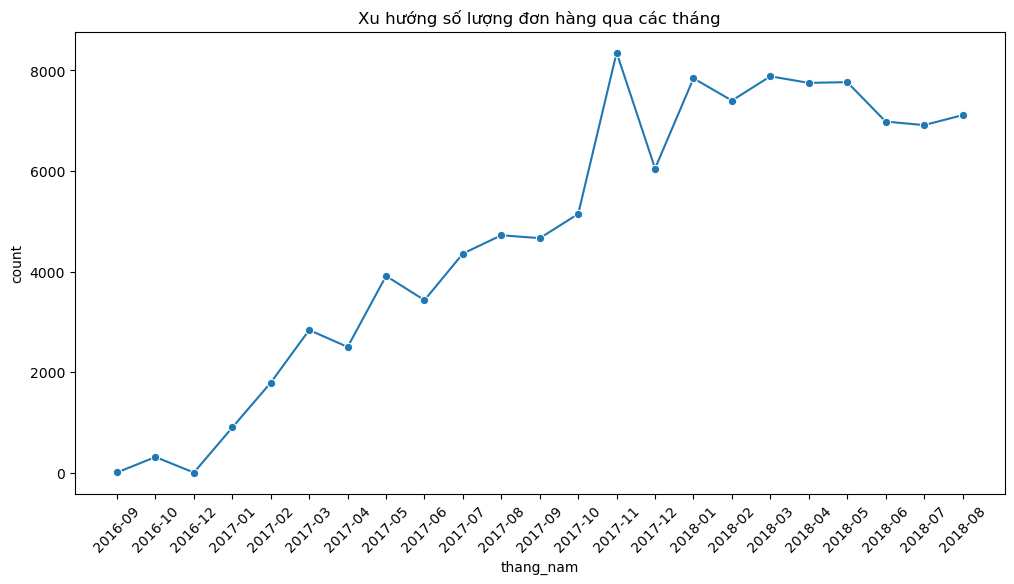

In [240]:
# chuyển dữ liệu sang Pandas
pdf_time = df_base.withColumn("thang_nam", F.date_format(F.to_date("order_purchase_timestamp"), "yyyy-MM")) \
         .groupBy("thang_nam").count().orderBy("thang_nam").toPandas()

# Vẽ biểu đồ
plt.figure(figsize=(12, 6))
sns.lineplot(data=pdf_time, x="thang_nam", y="count", marker='o')
plt.title("Xu hướng số lượng đơn hàng qua các tháng")
plt.xticks(rotation=45)
plt.show()

In [241]:
# Monthly trends for top categories
from pyspark.sql.functions import countDistinct

df_base_with_date = df_base.withColumn("year_month", F.date_format("order_purchase_timestamp", "yyyy-MM"))

monthly_cat = df_base_with_date \
    .groupBy("year_month", "product_category_name_english") \
    .agg(countDistinct("order_id").alias("num_orders")) \
    .orderBy("year_month", "num_orders", ascending=[True, False])

# Get top categories overall
top_cats_overall = df_base \
    .groupBy("product_category_name_english") \
    .agg(countDistinct("order_id").alias("total_orders")) \
    .orderBy("total_orders", ascending=False) \
    .limit(5)

top_cat_list = [row["product_category_name_english"] for row in top_cats_overall.collect()]

# Filter monthly data for top categories
monthly_top_cat = monthly_cat.filter(F.col("product_category_name_english").isin(top_cat_list))

monthly_top_cat.show(50)

+----------+-----------------------------+----------+
|year_month|product_category_name_english|num_orders|
+----------+-----------------------------+----------+
|   2016-09|                health_beauty|         1|
|   2016-10|              furniture_decor|        49|
|   2016-10|                health_beauty|        36|
|   2016-10|               sports_leisure|        17|
|   2016-10|         computers_accesso...|        12|
|   2016-10|               bed_bath_table|         5|
|   2017-01|              furniture_decor|       131|
|   2017-01|                health_beauty|        79|
|   2017-01|               sports_leisure|        56|
|   2017-01|               bed_bath_table|        43|
|   2017-01|         computers_accesso...|        24|
|   2017-02|              furniture_decor|       211|
|   2017-02|                health_beauty|       143|
|   2017-02|               bed_bath_table|       139|
|   2017-02|               sports_leisure|       133|
|   2017-02|         compute

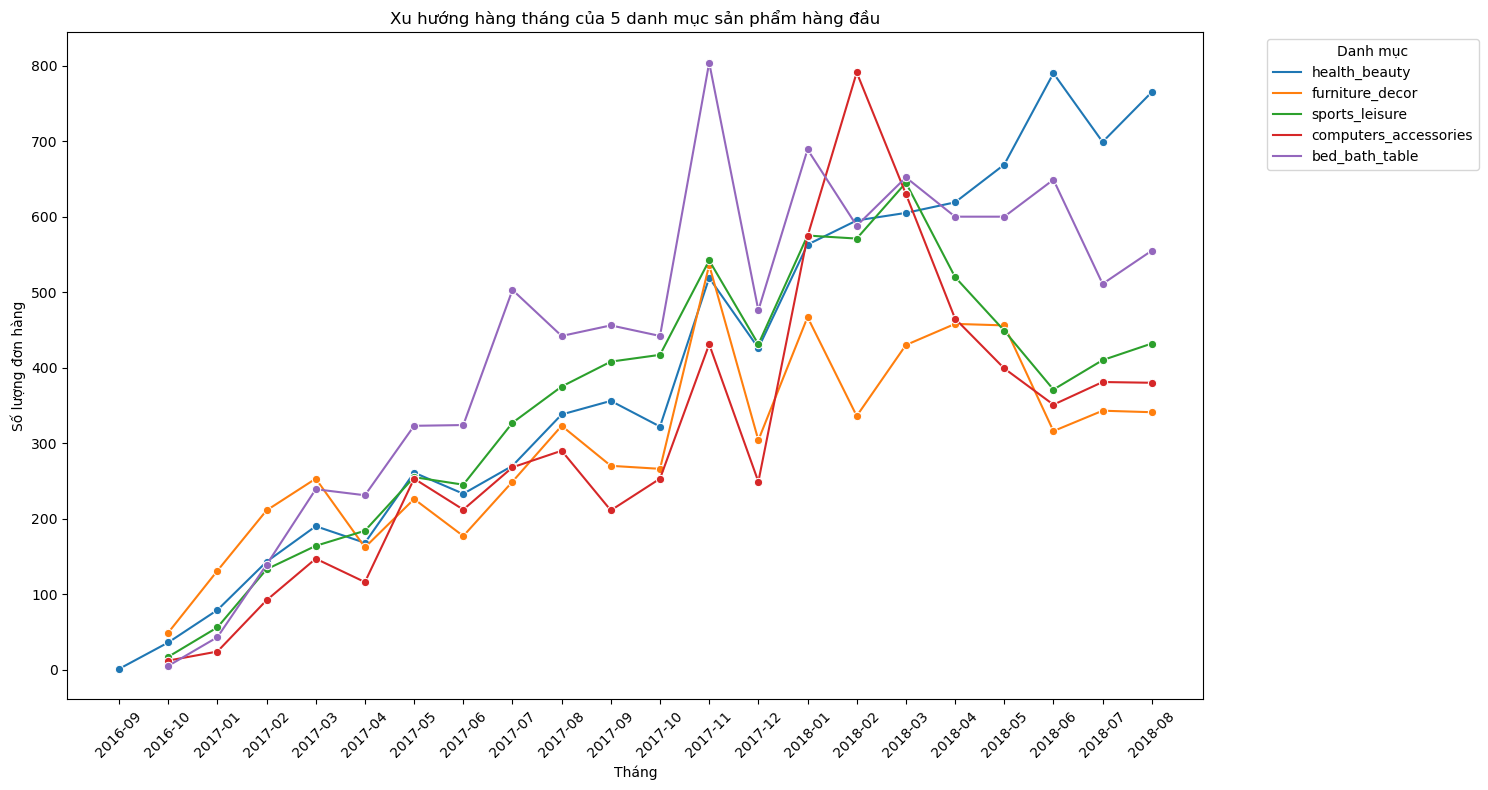

In [242]:
# Visualize monthly trends
pdf_monthly = monthly_top_cat.toPandas()

plt.figure(figsize=(15, 8))
sns.lineplot(data=pdf_monthly, x="year_month", y="num_orders", hue="product_category_name_english", marker="o")
plt.title("Xu hướng hàng tháng của 5 danh mục sản phẩm hàng đầu")
plt.xlabel("Tháng")
plt.ylabel("Số lượng đơn hàng")
plt.xticks(rotation=45)
plt.legend(title="Danh mục", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

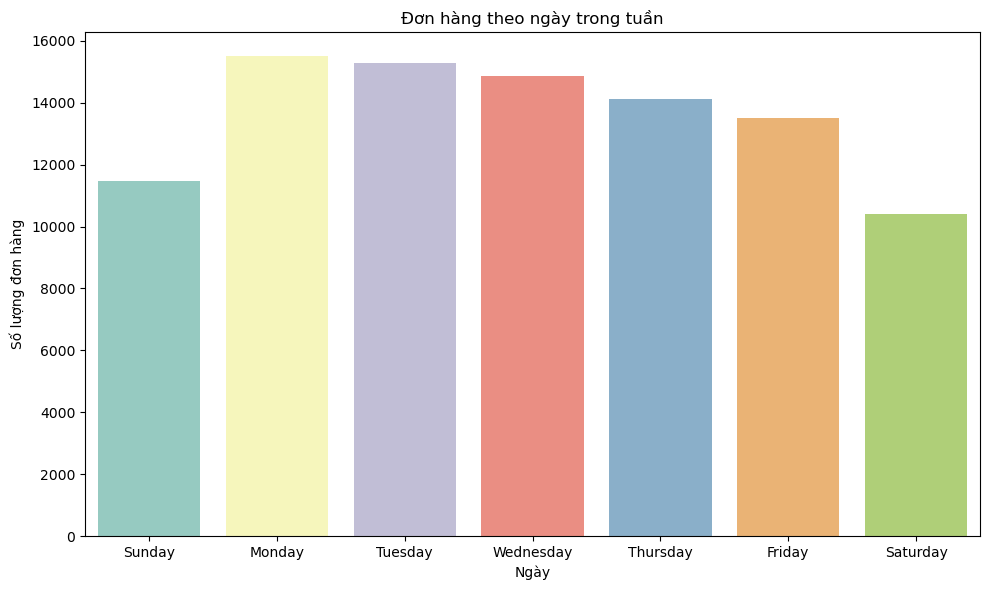

In [243]:
# Orders by day of week
dow_orders = df_base.groupBy("dayofweek") \
    .agg(F.countDistinct("order_id").alias("num_orders")) \
    .orderBy("dayofweek")

pdf_dow = dow_orders.toPandas()

# Map day numbers to names
day_names = {1: 'Sunday', 2: 'Monday', 3: 'Tuesday', 4: 'Wednesday', 5: 'Thursday', 6: 'Friday', 7: 'Saturday'}
pdf_dow['day_name'] = pdf_dow['dayofweek'].map(day_names)

plt.figure(figsize=(10, 6))
sns.barplot(data=pdf_dow, x="day_name", y="num_orders", palette="Set3")
plt.title("Đơn hàng theo ngày trong tuần")
plt.xlabel("Ngày")
plt.ylabel("Số lượng đơn hàng")
plt.tight_layout()
plt.show()

## Phân tích Associations: Sản phẩm thường được mua cùng nhau

In [ ]:
# 1. Gom các product_id trong cùng 1 đơn hàng 
multi_product_df = df_base.groupBy("order_id") \
    .agg(F.collect_set("product_id").alias("products")) \
    .filter(F.size("products") > 1)

# 2. Định nghĩa lại hàm tạo cặp (giữ nguyên logic cũ nhưng đổi tên biến cho dễ hiểu)
def get_product_pairs(product_list):
    pairs = []
    prods = sorted(list(set(product_list))) # Sort để tránh cặp (A,B) và (B,A) bị đếm riêng
    for i in range(len(prods)):
        for j in range(i+1, len(prods)):
            pairs.append((prods[i], prods[j]))
    return pairs

get_pairs_udf = udf(get_product_pairs, ArrayType(ArrayType(StringType())))

# 3. Thực thi tách cặp và đếm
product_pairs_df = multi_product_df.withColumn("pairs", get_pairs_udf("products")) \
    .withColumn("pair", F.explode("pairs")) \
    .select(
        F.col("pair").getItem(0).alias("prod_1"),
        F.col("pair").getItem(1).alias("prod_2")
    )

# 4. Thống kê top các cặp sản phẩm "hay đi cùng nhau"
top_product_pairs = product_pairs_df.groupBy("prod_1", "prod_2") \
    .count() \
    .orderBy("count", ascending=False)

top_product_pairs.show(20, truncate=False)
top_product_pairs.agg(F.sum("count").alias("total_count")).show()


+-------------------------+-------------------------+-----+
|prod_1                   |prod_2                   |count|
+-------------------------+-------------------------+-----+
|computers_accessories-3  |computers_accessories-5  |34   |
|bed_bath_table-1         |home_confort-1           |29   |
|auto-1                   |auto-5                   |17   |
|computers_accessories-5  |computers_accessories-8  |12   |
|garden_tools-1           |garden_tools-2           |11   |
|garden_tools-2           |garden_tools-4           |9    |
|garden_tools-3           |garden_tools-4           |8    |
|garden_tools-1           |garden_tools-4           |7    |
|computers_accessories-49 |computers_accessories-89 |6    |
|computers_accessories-57 |computers_accessories-9  |6    |
|bed_bath_table-106       |bed_bath_table-128       |6    |
|computers_accessories-13 |computers_accessories-46 |6    |
|computers_accessories-55 |computers_accessories-90 |6    |
|auto-15                  |auto-8       

In [248]:
# 1. Tách các cặp sản phẩm thành các dòng đơn lẻ (loại bỏ trùng lặp trong cặp)
# Sử dụng F.array_distinct và F.explode để chuyển cấu trúc (prod_1, prod_2) thành từng dòng product_id duy nhất
# Điều này giúp ta ánh xạ (map) trực tiếp từng sản phẩm trong cặp sang danh mục tương ứng, loại bỏ trùng lặp
single_products_from_pairs = top_product_pairs.select(
    "count", # Số lần cặp này xuất hiện cùng nhau
    F.explode(F.array_distinct(F.array("prod_1", "prod_2"))).alias("product_id")
)

# 2. Ánh xạ sản phẩm sang danh mục (Category)
# Lưu ý: Sử dụng bảng df_products_clean (đã lọc bỏ null) để join
category_stats = single_products_from_pairs.join(
    df_products_clean.select("product_id", "product_category_name"), 
    on="product_id", 
    how="inner"
)

# 3. Phân tích danh mục phổ biến nhất trong các chiến lược Cross-selling
# Ta cộng tổng 'count' để xác định danh mục nào thường xuyên góp mặt trong các tổ hợp mua sắm
top_categories_cross_sell = category_stats.groupBy("product_category_name") \
    .agg(F.sum("count").alias("total_support_count")) \
    .orderBy(F.desc("total_support_count"))

# 4. Hiển thị kết quả
top_categories_cross_sell.show(20, truncate=False)

+---------------------+-------------------+
|product_category_name|total_support_count|
+---------------------+-------------------+
+---------------------+-------------------+



In [247]:
# Tạo df_products_clean: lọc bỏ các sản phẩm có category null
df_products_clean = df_products.filter(F.col("product_category_name").isNotNull())

Nhận thấy khá nhiều cặp sản phẩm thuộc cùng danh mục. Tỷ lệ này là bao nhiêu? Liệu có phải hầu hết khách hàng chỉ mua đồ trong cùng một ngành hàng không?

In [ ]:
# 1. Định nghĩa UDF để tạo các cặp (Category_1, Category_2)
# Logic: Nếu đơn có {Sp A (Gia dụng), Sp B (Gia dụng), Sp C (Điện tử)}
# Sẽ tạo ra các cặp danh mục: (Gia dụng, Gia dụng), (Gia dụng, Điện tử), (Gia dụng, Điện tử)
def get_category_pairs(id_list, cat_list):
    # Kết hợp ID và Category để xử lý chính xác từng sản phẩm
    combined = list(set(zip(id_list, cat_list))) 
    combined.sort() # Sắp xếp để đảm bảo tính nhất quán
    
    cat_pairs = []
    for i in range(len(combined)):
        for j in range(i + 1, len(combined)):
            # Lấy category của sản phẩm i và sản phẩm j
            cat_pairs.append((combined[i][1], combined[j][1]))
    return cat_pairs

# Định nghĩa schema cho Output: Mảng các struct chứa 2 category
pair_schema = ArrayType(StructType([
    StructField("cat1", StringType()),
    StructField("cat2", StringType())
]))

get_cat_pairs_udf = udf(get_category_pairs, pair_schema)

# 2. Thực thi gom nhóm và tách cặp danh mục
category_pairs_df = df_base.groupBy("order_id") \
    .agg(
        F.collect_list("product_id").alias("ids"),
        F.collect_list("product_category_name_english").alias("cats")
    ) \
    .withColumn("pairs", get_cat_pairs_udf("ids", "cats")) \
    .filter(F.size("pairs") > 0) \
    .withColumn("pair", F.explode("pairs")) \
    .select(
        F.col("pair.cat1").alias("cat1"),
        F.col("pair.cat2").alias("cat2")
    )

# 3. Phân loại cặp: Nếu cat1 == cat2 thì là "Cùng danh mục"
final_report = category_pairs_df.withColumn(
    "is_same_category",
    F.when(F.col("cat1") == F.col("cat2"), "Cùng danh mục").otherwise("Khác danh mục")
).groupBy("is_same_category").count()

# 4. Tính tỷ lệ dựa trên TỔNG SỐ CẶP (không phải tổng số đơn)
total_pairs = category_pairs_df.count()

print(f"Tổng số cặp sản phẩm phân tích được: {total_pairs}")
final_report.withColumn("percentage", F.round((F.col("count") / total_pairs) * 100, 2)).show()

Tổng số cặp sản phẩm phân tích được: 4353
+----------------+-----+----------+
|is_same_category|count|percentage|
+----------------+-----+----------+
|   Cùng danh mục| 3497|     80.34|
|   Khác danh mục|  856|     19.66|
+----------------+-----+----------+



80,34% là Cùng danh mục và chỉ có 19,66% là Khác danh mục
Hành vi mua sắm của khách hàng hiện tại cực kỳ tập trung vào nội bộ ngành hàng. Việc gợi ý bán chéo (Cross-selling) khác ngành hàng hiện tại đang có dữ liệu rất thưa thớt
Câu hỏi đặt ra: "Trong nhóm 80% cùng ngành đó, ngành nào đang có sức mua nhiều và có dữ liệu dày nhất?". Cần biết ngành nào đóng góp nhiều nhất để chuẩn bị cho việc áp dụng các ngưỡng chỉ số (Support, Confidence) phù hợp 

Lọc riêng các cặp thuộc "Cùng danh mục" và thống kê xem ngành hàng nào xuất hiện nhiều nhất. Mục tiêu để xác định độ lớn mẫu của từng ngành hàng.

In [ ]:
# 1. Lọc ra các cặp sản phẩm thuộc CÙNG danh mục từ kết quả của bước trước giữ lại tên danh mục để biết cặp đó thuộc ngành nào
same_category_pairs = category_pairs_df.filter(F.col("cat1") == F.col("cat2")) \
    .select(F.col("cat1").alias("category"), "cat1", "cat2")

# 2. Thống kê số lượng cặp theo từng danh mục
# Mục đích: Xem ngành hàng nào có xu hướng "mua cùng loại" nhiều nhất
category_ranking = same_category_pairs.groupBy("category") \
    .count() \
    .orderBy("count", ascending=False)

# 3. Tính thêm tỷ lệ phần trăm đóng góp của mỗi ngành trong nhóm "Cùng danh mục"
total_same_cat = same_category_pairs.count()
category_ranking_with_pct = category_ranking.withColumn(
    "contribution_pct", 
    F.round((F.col("count") / total_same_cat) * 100, 2)
)

print("Bảng xếp hạng các danh mục có hành vi mua kèm nội bộ cao nhất:")
category_ranking_with_pct.show(20, truncate=False)

Bảng xếp hạng các danh mục có hành vi mua kèm nội bộ cao nhất:
+-------------------------------+-----+----------------+
|category                       |count|contribution_pct|
+-------------------------------+-----+----------------+
|bed_bath_table                 |909  |25.99           |
|furniture_decor                |446  |12.75           |
|computers_accessories          |221  |6.32            |
|health_beauty                  |205  |5.86            |
|watches_gifts                  |201  |5.75            |
|housewares                     |154  |4.4             |
|sports_leisure                 |151  |4.32            |
|fashion_bags_accessories       |138  |3.95            |
|toys                           |120  |3.43            |
|auto                           |108  |3.09            |
|garden_tools                   |105  |3.0             |
|perfumery                      |92   |2.63            |
|telephony                      |90   |2.57            |
|construction_tools_const

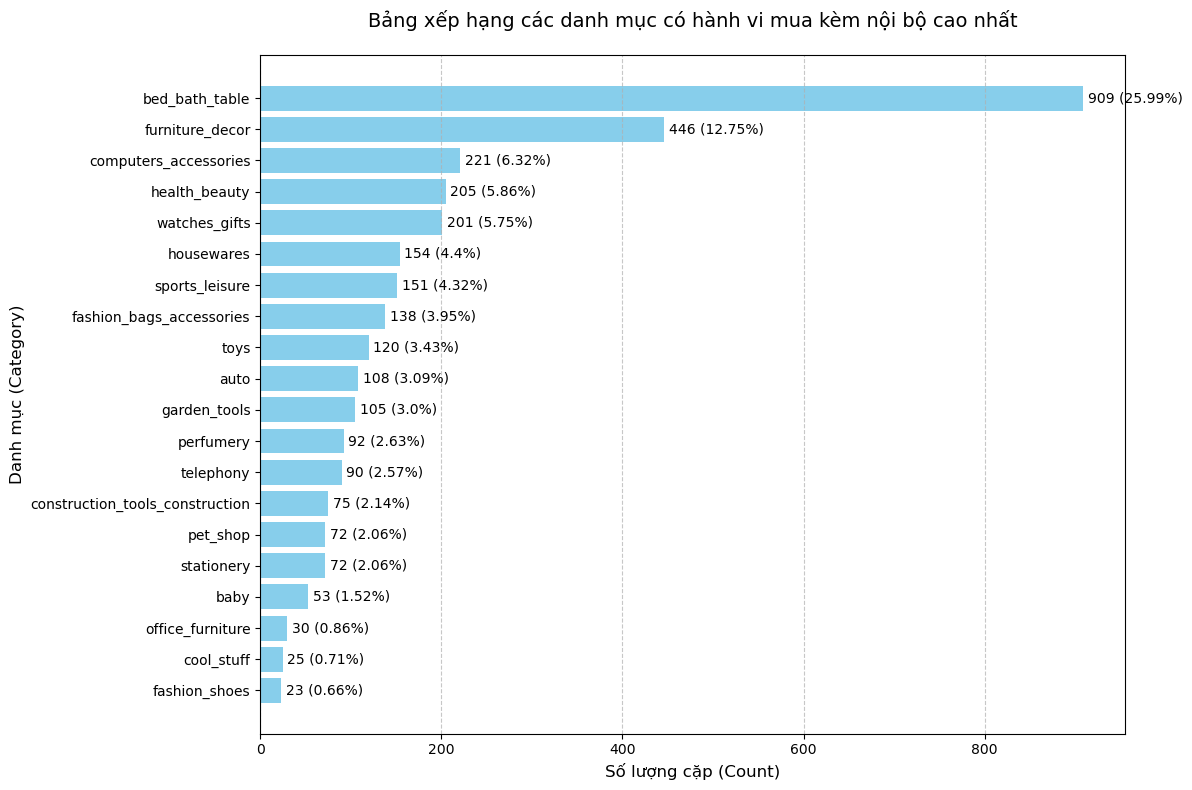

In [ ]:
#  Chỉ lấy Top 20 để biểu đồ không bị quá dày
pdf = category_ranking_with_pct.limit(20).toPandas()
plt.figure(figsize=(12, 8))
# Vẽ biểu đồ cột ngang 
# Dùng [::-1] để danh mục cao nhất nằm ở trên cùng
bars = plt.barh(pdf['category'][::-1], pdf['count'][::-1], color='skyblue')
for bar, pct in zip(bars, pdf['contribution_pct'][::-1]):
    plt.text(
        bar.get_width() + 5, 
        bar.get_y() + bar.get_height()/2, 
        f'{int(bar.get_width())} ({pct}%)', 
        va='center', 
        fontsize=10
    )
plt.title('Bảng xếp hạng các danh mục có hành vi mua kèm nội bộ cao nhất', fontsize=14, pad=20)
plt.xlabel('Số lượng cặp (Count)', fontsize=12)
plt.ylabel('Danh mục (Category)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

# Hiển thị biểu đồ
plt.show()

Có một sự phân hóa rất rõ rệt: Bed_Bath_Table và Furniture_Decor chiếm tới gần 39% tổng số cặp cùng danh mục, trong khi các nhóm phía dưới giảm rất nhanh.
Do sự chênh lệch lớn giữa các danh mục (73 danh mục - 2 danh mục chưa có tên tiếng anh mới được thêm vào), việc áp dụng các ngưỡng cố định cho bộ ba chỉ số Support, Confidence, và Lift sẽ không phản ánh chính xác tiềm năng của các nhóm ở quy mô nhỏ hơn. 

Giải pháp: Cần phân nhóm dữ liệu. Việc thiết lập ngưỡng linh hoạt theo từng nhóm sẽ giúp xác định chính xác những cặp sản phẩm có giá trị khai thác cao mà không bỏ lỡ các danh mục long-tail của biểu đồ.

Dựa trên biểu đồ ta có thể phân như sau: 
- Nhóm 1: top 1 + top 2. Nếu áp dụng cùng một mức Support cho toàn sàn thì hoặc là sẽ bị ngập trong gợi ý của 2 ngành này, hoặc là sẽ bỏ lỡ hoàn toàn các ngành khác.
- Nhóm 2: từ top 3 đến top 15. Các ngành như computers_accessories, health_beauty, toys, auto... có mức đóng góp từ 2.5% đến 6%.
- Nhóm 3: top 20 trở đi. Bắt đầu từ office_furniture (0.86%) trở xuống đến tận danh mục thứ 71

Mỗi nhóm sẽ có một mức support riêng. Support thấp có khiến luật trở nên ít đáng tin cậy không? 
Dù Support rất thấp nhưng Lift cao sẽ khẳng định rằng mối quan hệ này là có thật và cực mạnh. Nếu khách đã chạm vào sản phẩm này, khả năng cao họ sẽ mua sản phẩm kia dù chúng khác danh mục.

In [ ]:
# Thêm cột rank
windowSpec = Window.orderBy(F.desc("count"))
ranked_categories = category_ranking_with_pct.withColumn("rank", F.row_number().over(windowSpec))

# Chia nhóm theo rank
grouped_categories = ranked_categories.withColumn(
    "group",
    F.when(F.col("rank") <= 2, "Group 1") \
     .when((F.col("rank") >= 3) & (F.col("rank") <= 15), "Group 2") \
     .otherwise("Group 3")
)

grouped_categories.show(30, truncate=False)
# Đếm số lượng danh mục trong từng nhóm
group_counts = grouped_categories.groupBy("group") \
    .agg(F.countDistinct("category").alias("num_categories"))

group_counts.show()



+-------------------------------+-----+----------------+----+-------+
|category                       |count|contribution_pct|rank|group  |
+-------------------------------+-----+----------------+----+-------+
|bed_bath_table                 |909  |25.99           |1   |Group 1|
|furniture_decor                |446  |12.75           |2   |Group 1|
|computers_accessories          |221  |6.32            |3   |Group 2|
|health_beauty                  |205  |5.86            |4   |Group 2|
|watches_gifts                  |201  |5.75            |5   |Group 2|
|housewares                     |154  |4.4             |6   |Group 2|
|sports_leisure                 |151  |4.32            |7   |Group 2|
|fashion_bags_accessories       |138  |3.95            |8   |Group 2|
|toys                           |120  |3.43            |9   |Group 2|
|auto                           |108  |3.09            |10  |Group 2|
|garden_tools                   |105  |3.0             |11  |Group 2|
|perfumery          

# Chạy thử FP-GROWTH

In [ ]:
from pyspark.ml.fpm import FPGrowth

def run_fpgrowth_for_group(df, cat_list, min_sup, min_conf):
    # 1. Tìm các order_id có ít nhất 1 sản phẩm thuộc danh mục trong nhóm
    relevant_orders = df.filter(F.col("product_category_name_english").isin(cat_list)) \
                        .select("order_id").distinct()
    
    # 2. Lấy TOÀN BỘ sản phẩm của các đơn hàng đó
    group_df = df.join(relevant_orders, "order_id")
    
    # 3. Gom nhóm đơn hàng
    transactions = group_df.groupBy("order_id").agg(F.collect_set("product_id").alias("items"))
    
    # 4. Thực thi FP-Growth
    fp = FPGrowth(itemsCol="items", minSupport=min_sup, minConfidence=min_conf)
    model = fp.fit(transactions)
    
    return model.associationRules

# --- PHẦN THỰC THI ---

# Trích xuất danh sách categor
cat_list_g1 = [row['category'] for row in grouped_categories.filter(F.col("group") == "Group 1").select("category").collect()]
cat_list_g2 = [row['category'] for row in grouped_categories.filter(F.col("group") == "Group 2").select("category").collect()]
cat_list_g3 = [row['category'] for row in grouped_categories.filter(F.col("group") == "Group 3").select("category").collect()]

# Chạy luật cho từng nhóm
rules_g1 = run_fpgrowth_for_group(df_base, cat_list_g1, 0.005, 0.1)
rules_g2 = run_fpgrowth_for_group(df_base, cat_list_g2, 0.001, 0.05)
rules_g3 = run_fpgrowth_for_group(df_base, cat_list_g3, 0.0005, 0.01)

# Gộp kết quả
final_rules = rules_g1.union(rules_g2).union(rules_g3)

# Sắp xếp theo Lift để tìm ra những Cross-category
print("KẾT QUẢ LUẬT KẾT HỢP TỐI ƯU TOÀN SÀN:")
final_rules.orderBy(F.desc("lift")).show(20, truncate=False)

KẾT QUẢ LUẬT KẾT HỢP TỐI ƯU TOÀN SÀN:
+----------------------------------+----------------------------------+------------------+------------------+---------------------+
|antecedent                        |consequent                        |confidence        |lift              |support              |
+----------------------------------+----------------------------------+------------------+------------------+---------------------+
|[99a4788cb24856965c36a24e339b6058]|[35afc973633aaeb6b877ff57b2793310]|0.9666666666666667|133.48213507625272|0.0013726511099540872|
|[35afc973633aaeb6b877ff57b2793310]|[99a4788cb24856965c36a24e339b6058]|0.1895424836601307|133.48213507625272|0.0013726511099540872|
+----------------------------------+----------------------------------+------------------+------------------+---------------------+



## TÓM TẮT INSIGHTS CHO CROSS-SELLING

### Địa điểm (Location-based):
- **SP (São Paulo)** là bang có nhiều đơn hàng nhất (~40%), tập trung vào các category: bed_bath_table, health_beauty, sports_leisure
- **RJ (Rio de Janeiro)**: furniture_decor, health_beauty  
- **MG (Minas Gerais)**: bed_bath_table, furniture_decor
- Khác biệt theo vùng cho phép personalized recommendations

### Thời gian (Time-based):
- Xu hướng tăng trưởng tổng thể từ 2017-2018
- Giờ cao điểm: 10-16h, thấp nhất 3-6h sáng
- Ngày trong tuần: cao nhất Thứ 2-5, thấp nhất Chủ nhật
- Seasonal patterns: một số category tăng vào cuối năm

### Product Associations:
- Các cặp sản phẩm thường mua cùng: bed_bath_table + furniture_decor, health_beauty + watches_gifts
- ~25% đơn hàng có multiple products - tiềm năng cross-selling tốt

### Recommendations cho Gold Layer:
- Sử dụng location + time context để tạo association rules
- Cluster customers theo behavior patterns
- Implement collaborative filtering với temporal và geographical factors